# Critical Pre-field Analysis at (20 K)
**Device:** FGT-OFGT-CrPS4

**Data Folder:** `Device2/Data from 12T cryostat/Different pre field 20K`  


In [1]:
import re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import sys
sys.path.insert(0, str(Path().resolve().parent))
from scripts.data_loader import (
    load_h5, load_txt, get_file_list,
    offset_and_AHE, normalize,
    coercivity_zero_crossing, coercivity_largest_jump,
    exchange_bias, coercive_width,
    sort_serial, fixjump,
)
from scripts.notebook_setup import setup
setup()

PROJECT_ROOT = Path().resolve().parent
D2 = PROJECT_ROOT / 'data' / 'Device2'

[OK] Autoreload enabled
[OK] Project root (installed package): C:\Users\sadit\OneDrive - JGU\Projects\EB in FGT-OFGT_CrPS4
[OK] Matplotlib configured (Okabe-Ito palette, publication style)
Setup complete!


In [2]:
FOLDER_CRIT = D2 / 'Data_from_12T_cryostat' / 'Different_pre_field_20K'

T_crit, H1_crit, H2_crit = [], [], []
Field_crit, Vxy_norm_crit, Vxy_err_crit, Vxx_crit = [], [], [], []
Vahe_crit, Vahe_err_crit, R_crit = [], [], []

for fp in get_file_list(FOLDER_CRIT, ext=('.txt',)):
    d = load_txt(fp, skiprows=15, vxy_col='Voltage-2 (V)', trim='head')
    F = d['Field'];  Sig = d['Vxy'].copy();  ref = d['Vxx']
    Serr = d['Vxy_err'];  T = d['T']
    if fp.name.endswith('fix.txt'):
        Sig = fixjump(Sig, 0.5)
    offset, _, Vahe, Vahe_err = offset_and_AHE(Sig)
    Sig_norm = normalize(Sig, offset, Vahe)
    HC_neg, HC_pos = coercivity_zero_crossing(F, Sig_norm)
    HEB = exchange_bias(HC_neg, HC_pos)
    HC  = coercive_width(HC_neg, HC_pos)
    T_crit.append(T);  H1_crit.append(HC_neg);  H2_crit.append(HC_pos)
    Field_crit.append(F);  Vxy_norm_crit.append(Sig_norm)
    Vxy_err_crit.append(Serr);  Vxx_crit.append(ref)
    Vahe_crit.append(float(Vahe));  Vahe_err_crit.append(float(Vahe_err))
    peak = np.max(ref);  idx_r = np.abs(ref - peak) < 0.5
    R_crit.append(np.mean(ref[idx_r]) if idx_r.any() else peak)

    # F1 per file: Vxy
    #plt.figure()
    #plt.xlabel('Magnetic Field (mT)');  plt.ylabel('Vxy (uV)')
    #plt.title(f'T = {T} K  EB = {int(HEB)} mT')
    #plt.plot(F, Sig);  plt.errorbar(F, Sig, Serr, fmt='o')
    #plt.tight_layout();  plt.show()

T_crit    = np.array(T_crit)
W_crit    = np.abs(np.array(H1_crit) - np.array(H2_crit))
HEB_crit  = (np.array(H1_crit) + np.array(H2_crit)) / 2
Vahe_crit = np.array(Vahe_crit);  Vahe_err_crit = np.array(Vahe_err_crit)
R_crit    = np.array(R_crit)

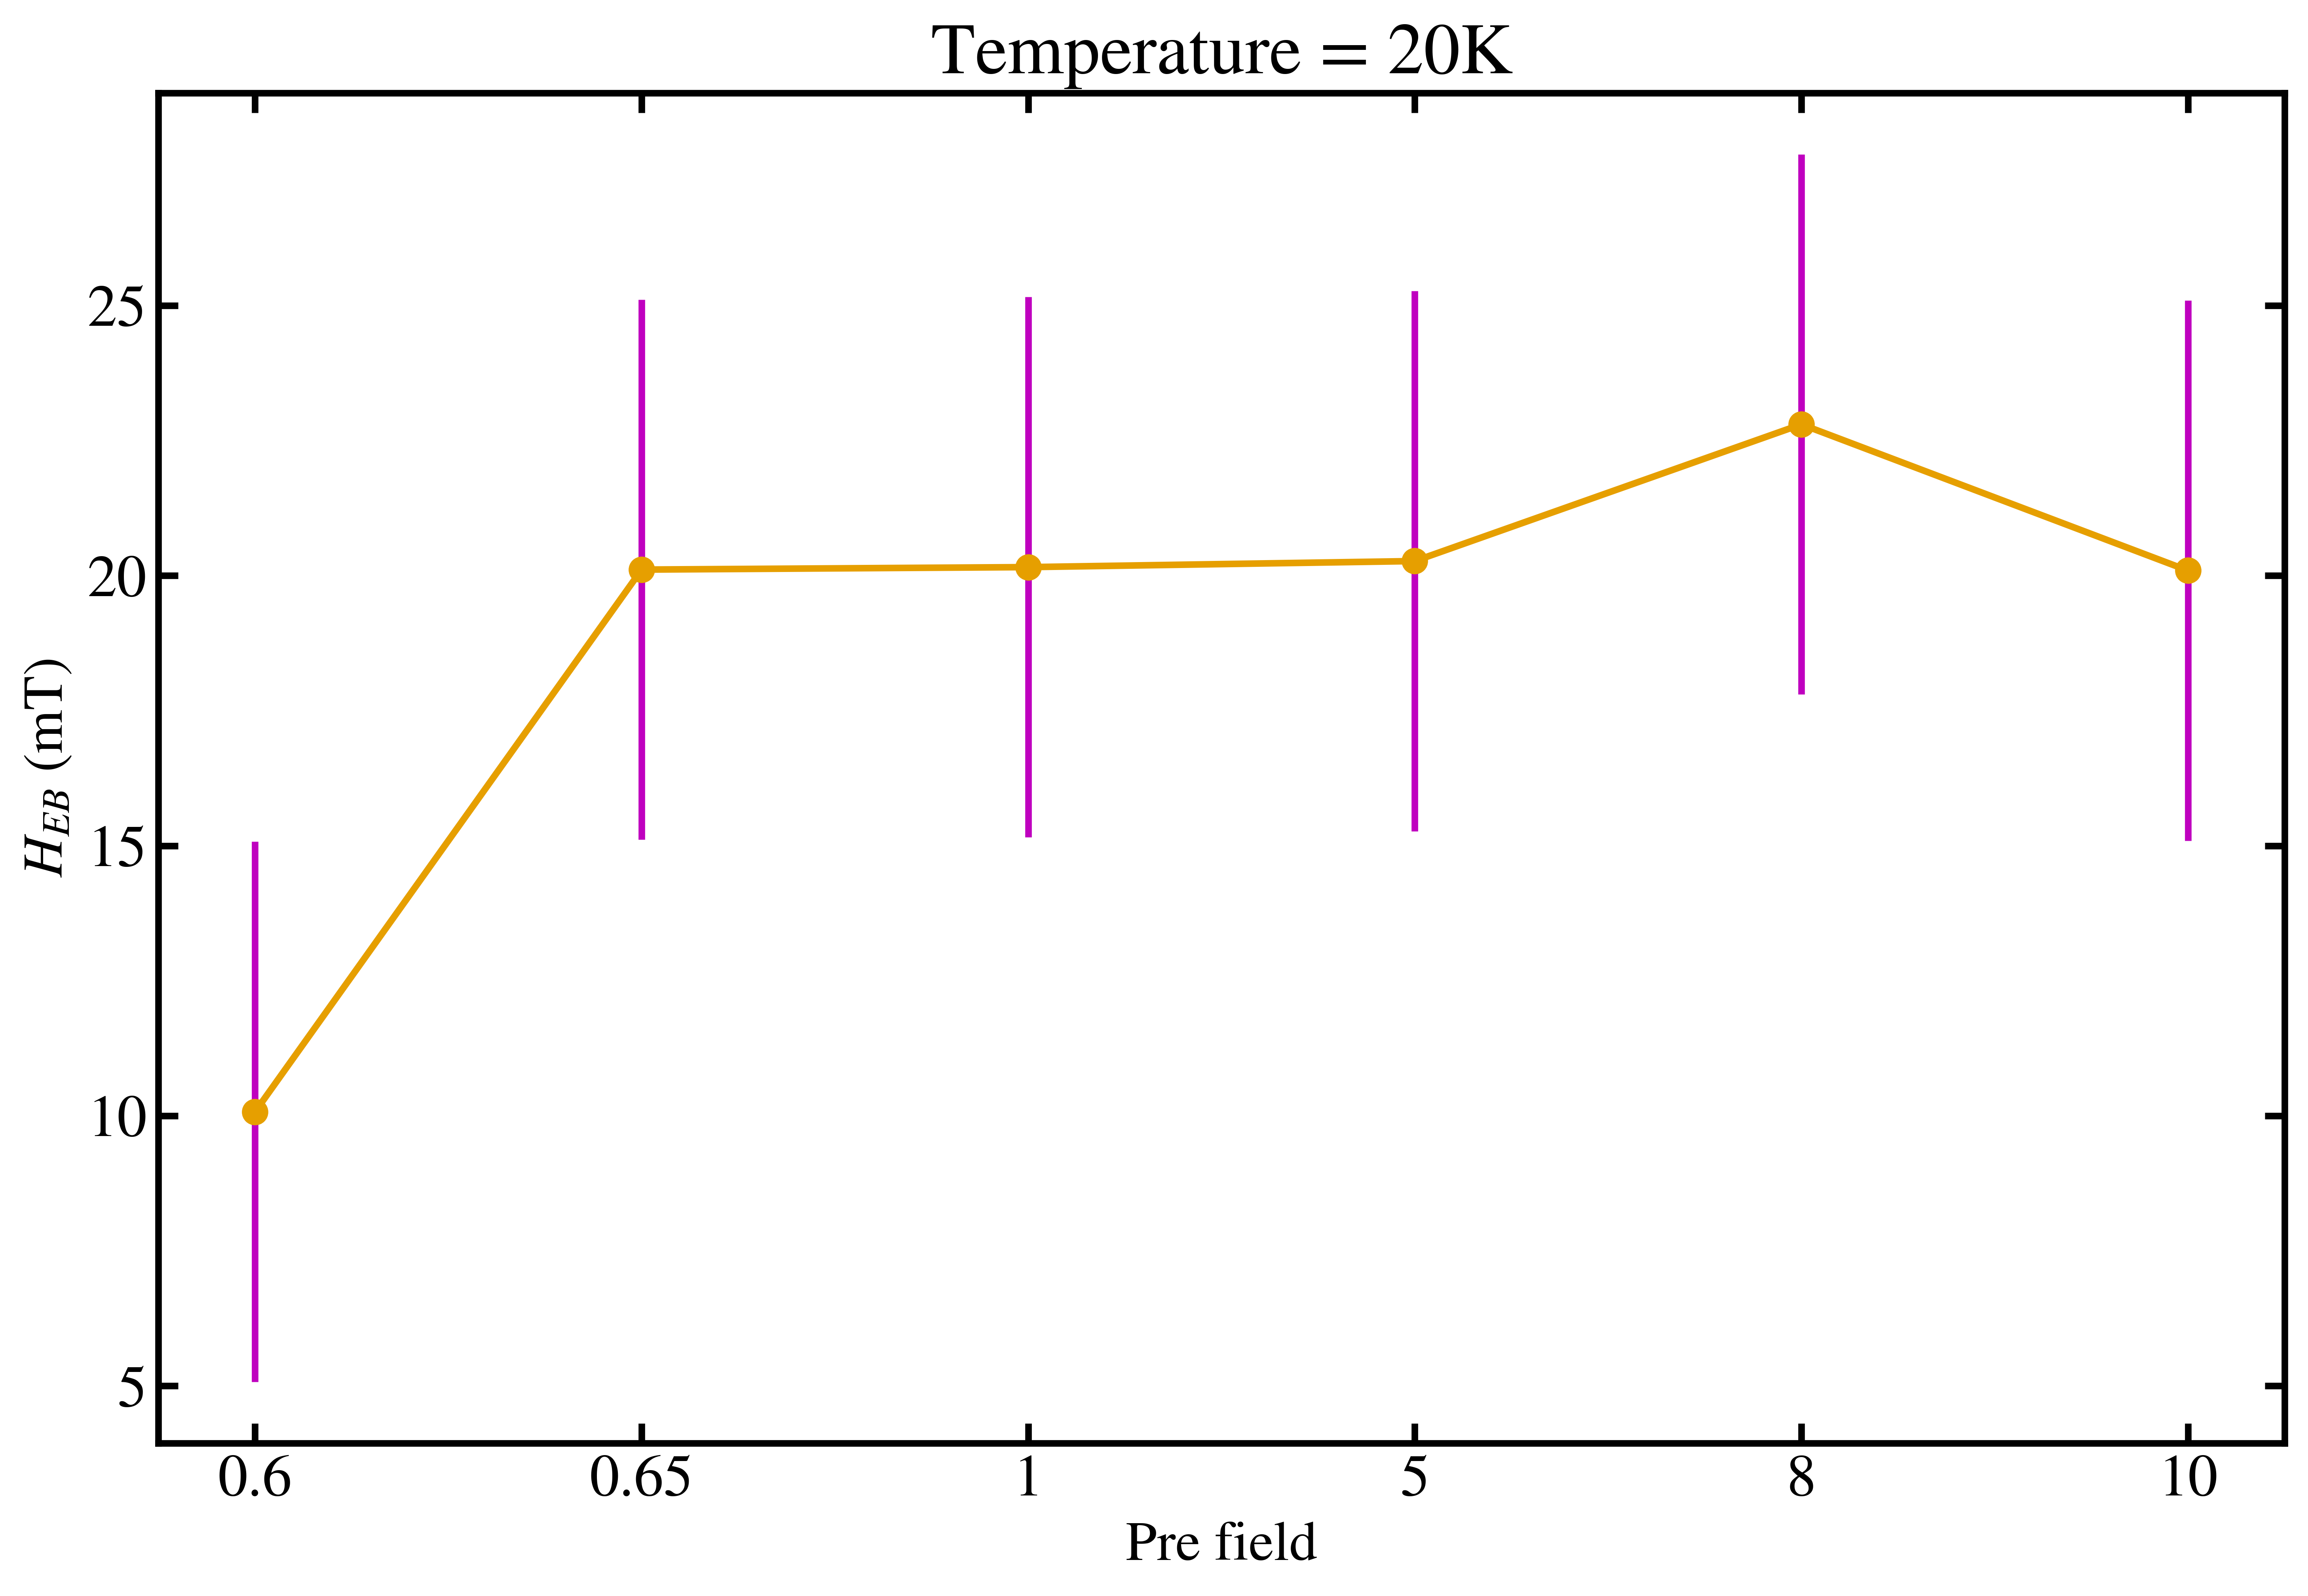

In [3]:
FC_labels = np.array(['0.6', '0.65', '1', '5', '8', '10'])
errorbars = np.array([5, 5, 5, 5, 5, 5])


# F5: |H_EB| vs pre-field
fig, ax = plt.subplots(dpi=600)
ax.set_ylabel('$H_{EB}$ (mT)', fontsize=17)
ax.errorbar(FC_labels, np.abs(HEB_crit), yerr=errorbars, fmt='-o', ecolor='m')
ax.set_xlabel('Pre field', fontsize=17)
plt.title('Temperature = 20K')
plt.tight_layout();  plt.show()

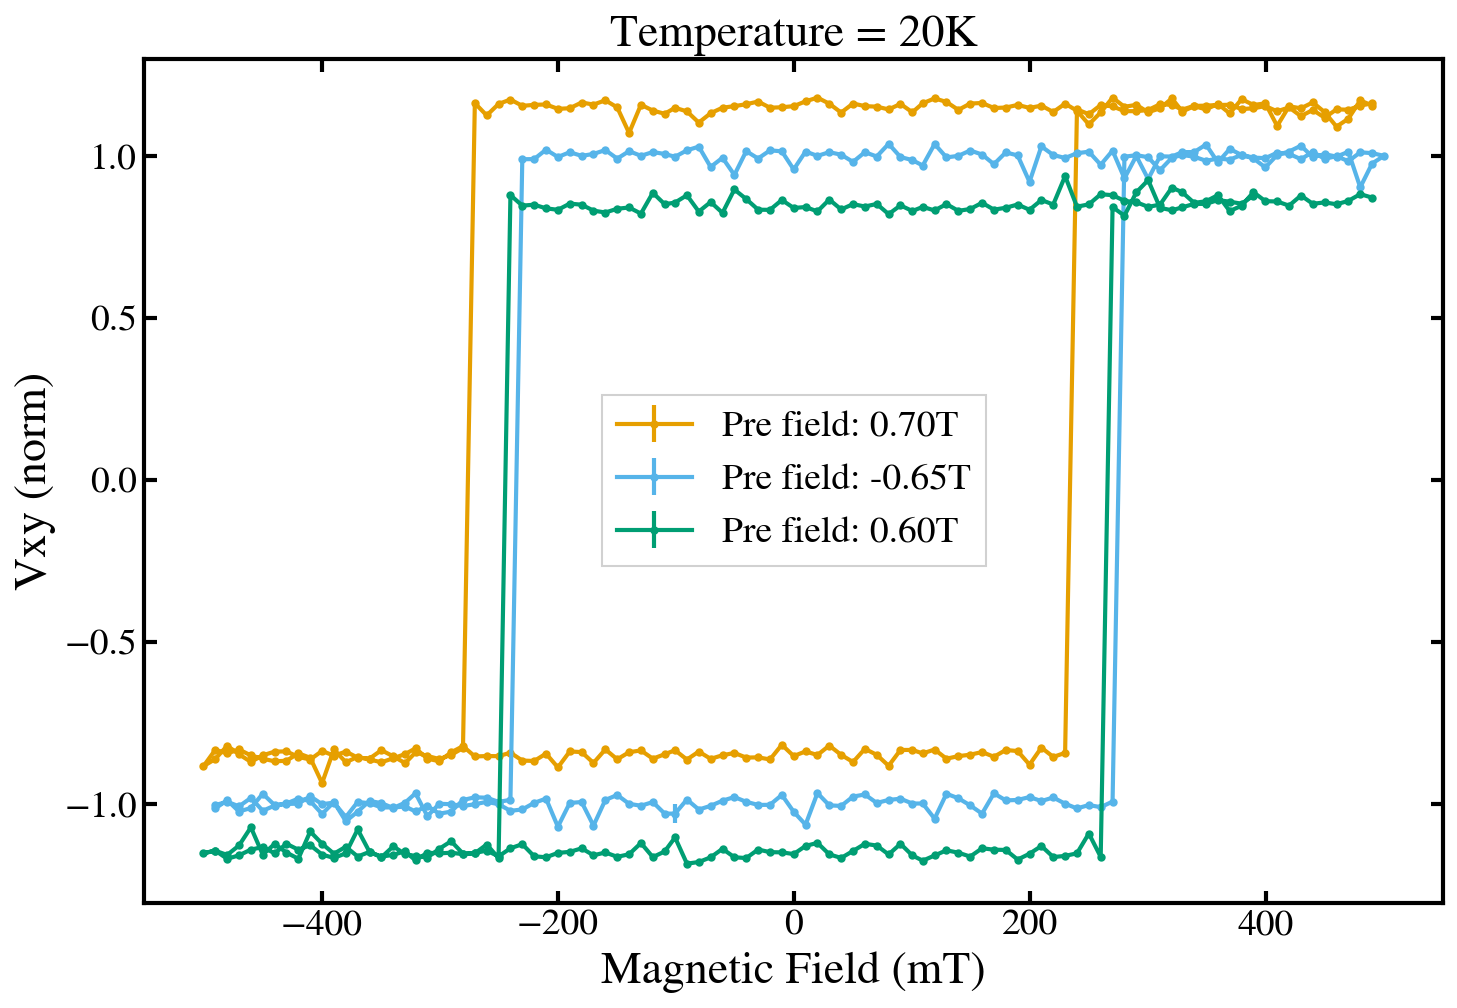

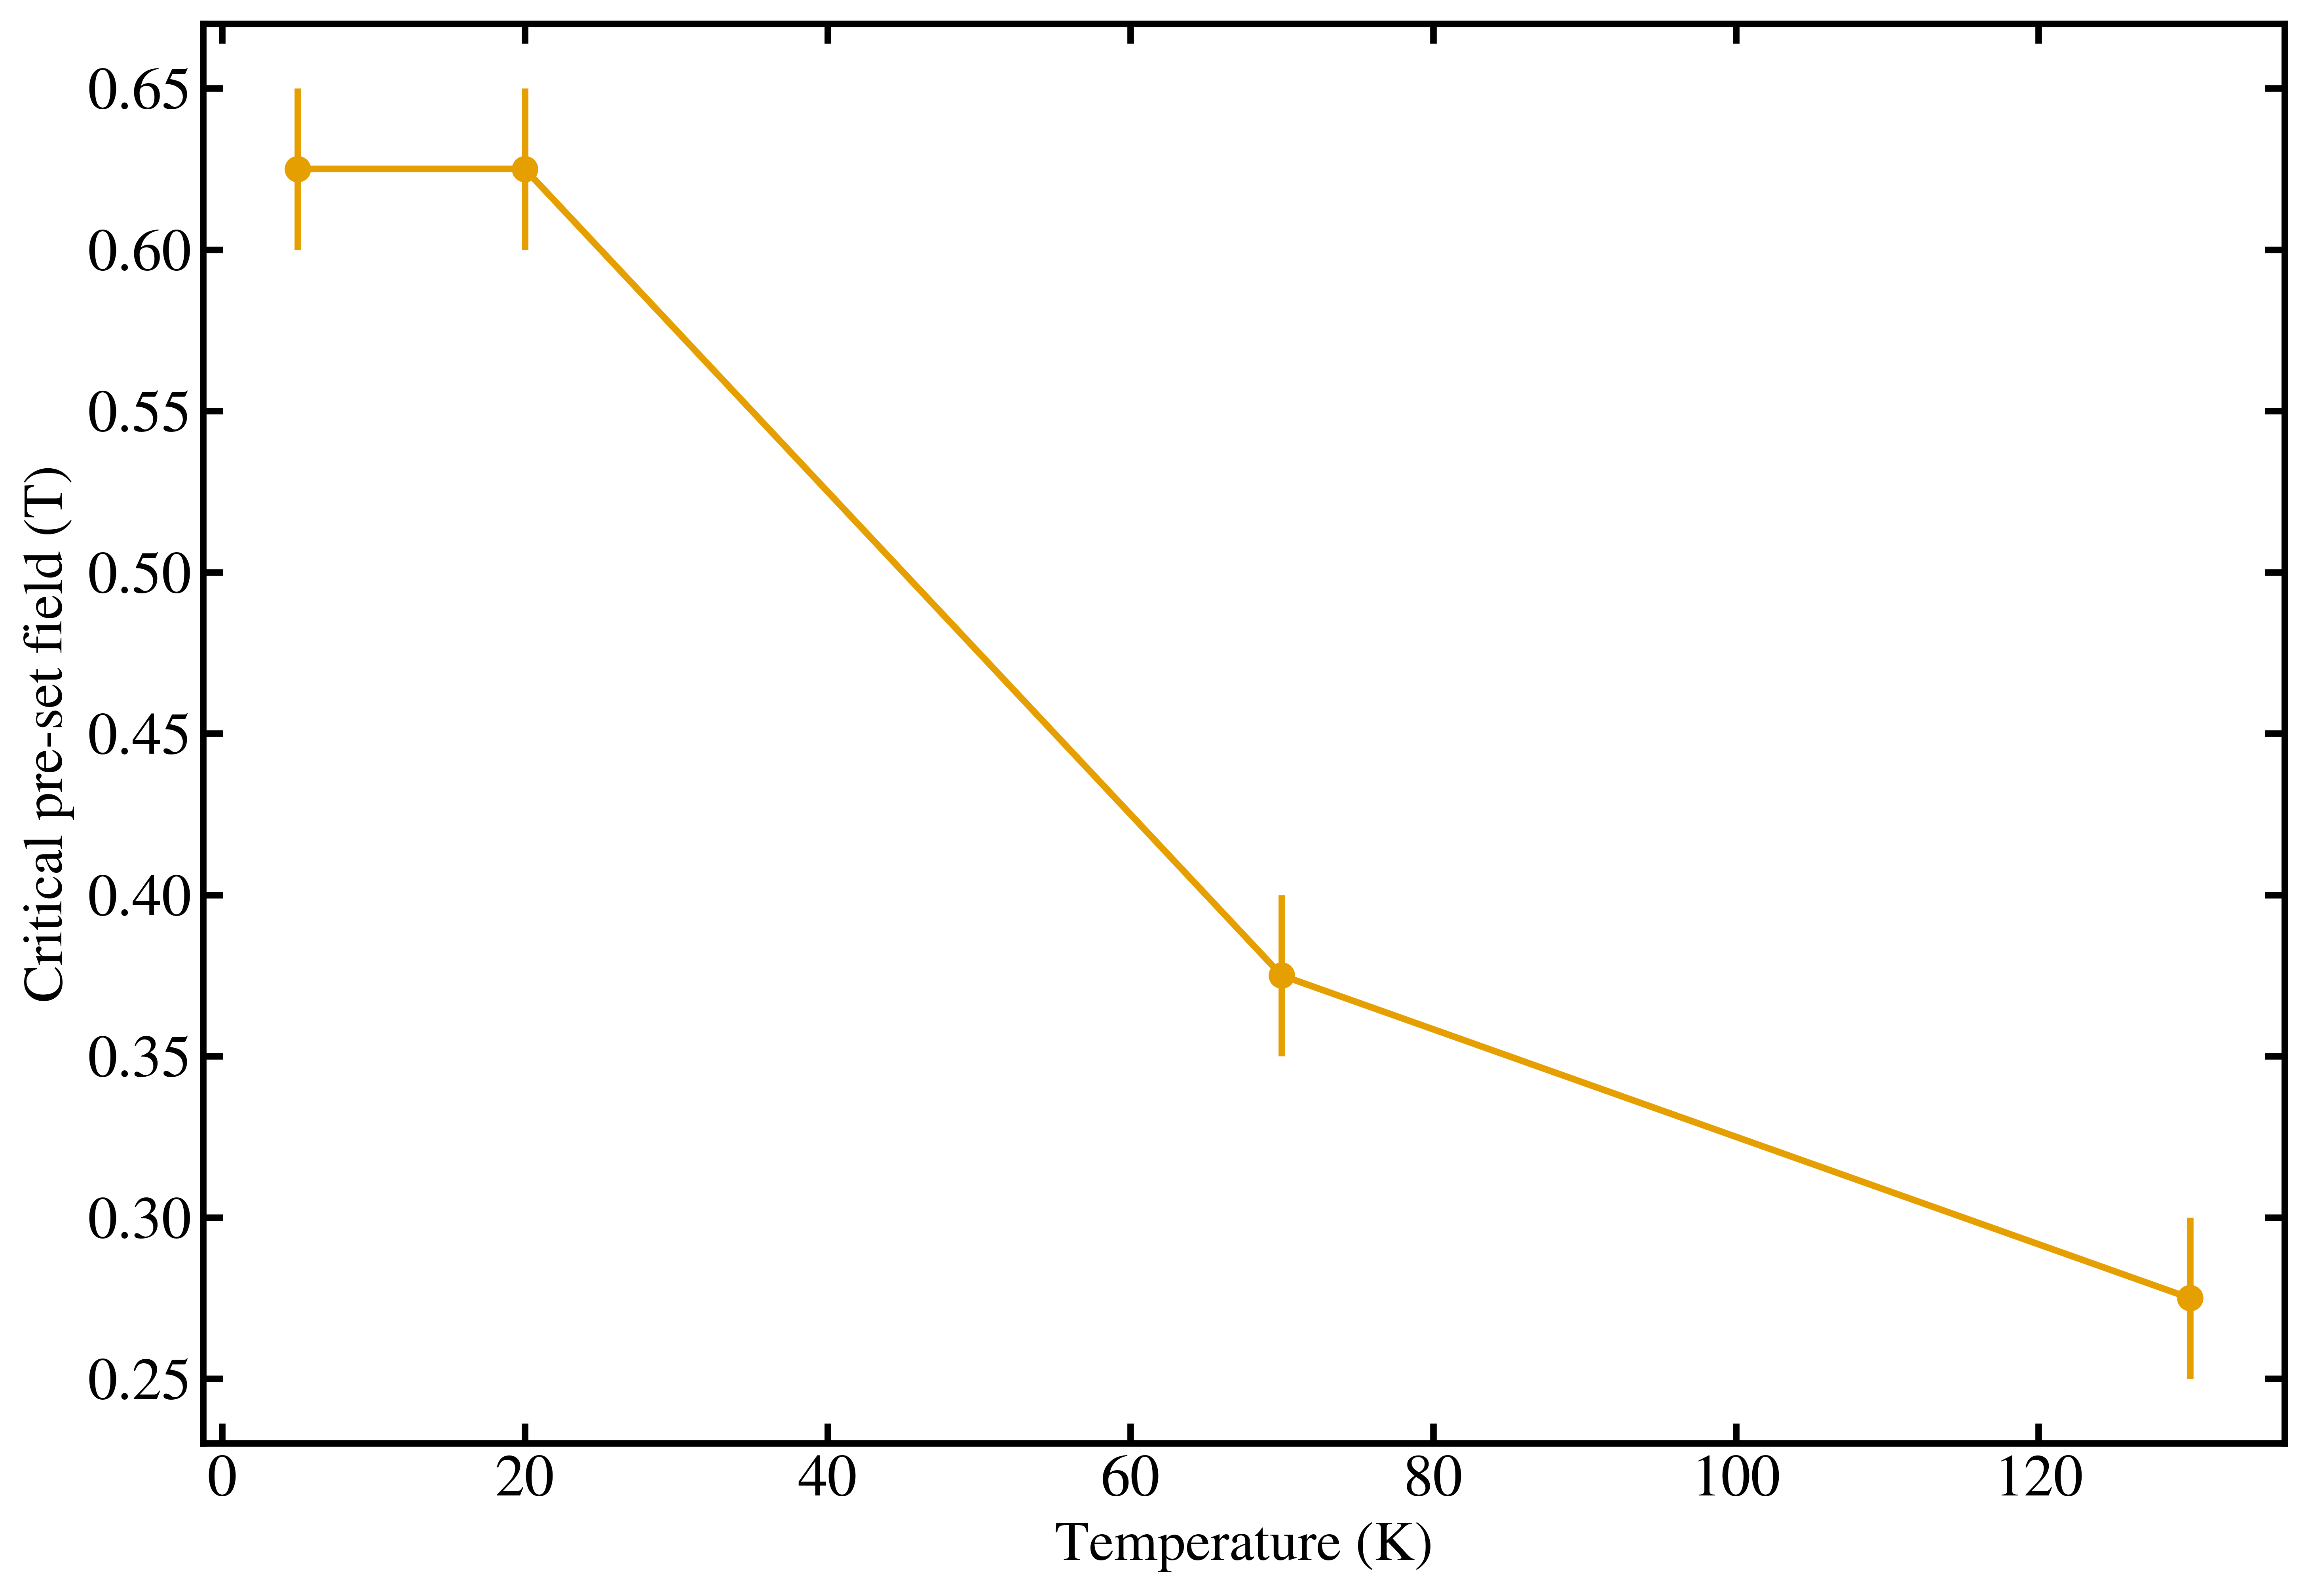

In [4]:
# F6: Waterfall â€” 3 selected loops
# Field_g[2]+0.15, Field_g[1]+0, -1*Field_g[0]-0.15 (field AND signal sign flipped for idx=0)
# errorbars normalised by Vahe
plt.figure()
plt.xlabel('Magnetic Field (mT)');  plt.ylabel('Vxy (norm)')
plt.errorbar(Field_crit[2], Vxy_norm_crit[2] + 0.15,
             Vxy_err_crit[2] / Vahe_crit[2], fmt='-o', markersize=3)
plt.errorbar(Field_crit[1], Vxy_norm_crit[1],
             Vxy_err_crit[1] / Vahe_crit[1], fmt='-o', markersize=3)
plt.errorbar(-1 * Field_crit[0], -1 * Vxy_norm_crit[0] - 0.15,
             Vxy_err_crit[0] / Vahe_crit[0], fmt='-o', markersize=3)
plt.legend(['Pre field: 0.70T', 'Pre field: -0.65T', 'Pre field: 0.60T'])
plt.title('Temperature = 20K')
plt.tight_layout();  plt.show()

# F7: Critical pre-set field vs T â€” hardcoded data
plt.figure(dpi=600)
x_crit = [5, 20, 70, 130]
y_crit = [0.625, 0.625, 0.375, 0.275]
err_crit = [0.025, 0.025, 0.025, 0.025]
plt.errorbar(x_crit, y_crit, err_crit, fmt='-o')
plt.xlabel('Temperature (K)', fontsize=17);  plt.ylabel('Critical pre-set field (T)', fontsize=17)
plt.tight_layout();  plt.show()